# US equities panel: a model that carries state across the window

[`06_linear`](06_linear.ipynb), [`07_gbm`](07_gbm.ipynb) and
[`08_tabular_dl`](08_tabular_dl.ipynb) all read the same flat table: one row per stock per
session, one column per feature, and nothing in the representation saying the rows are ordered
in time. A model on that table sees the past only through columns somebody computed in advance -
a 21-session momentum, a rolling volatility. It never sees the sequence itself.

A **sequence model** is handed the sequence. Each training example here is a **window**: the 60
most recent sessions of one stock's features, in order, as a matrix of sessions by features -
about three months. The model reads the window and emits one number, the predicted return.

**A window has to be 60 consecutive sessions of the same stock, and on this panel that binds.**
A stock that lists part-way through a fold, halts, or delists leaves a gap, and a window
spanning a gap would treat the two sides as consecutive sessions and read the jump across it as
one day's move. Windows are therefore built only where the sessions are unbroken, which is why
the number of training examples is far smaller than the number of rows and differs between
folds.

[`09_dl_nlinear`](09_dl_nlinear.ipynb) read each window as one fixed-length input and applied a
single linear map to it. An **LSTM** reads the window one session at a time instead, carrying a
**hidden state** forward: a vector summarising everything it has seen so far, updated at each
step and used to predict at the end.

**What the architecture adds is a decision about what to keep.** At each step three learned
gates decide how much of the new session to admit, how much of the existing state to discard,
and how much of the state to expose. That is what lets a recurrent model carry something from
the start of a window to its end without it being diluted at every step, which a plain recurrent
network cannot do.

The configuration here stacks two such layers with a hidden state of 64. Two layers rather than
one so the second reads a sequence of summaries rather than a sequence of observations; 64
rather than more because the training examples are windows, not rows, and the window count is
what bounds how much capacity can be estimated from them.

**Learning objectives.** By the end of this notebook you will be able to:

- Describe what a hidden state is and what the gates of an LSTM decide at each step.
- Say what a recurrent model can represent that a single linear map over the same window cannot.
- Explain why the number of eligible windows, rather than the number of panel rows, is what
  bounds the capacity worth fitting.
- Read the epoch schedule out of a declared configuration and say how many scoreable models the
  run publishes for it.

**A neural fit has a meaningful state at every epoch**, in the way a boosted model has one at
every iteration and a linear fit does not. An **epoch** is one pass over the training windows.
Each configuration here trains for 100 of them and saves its weights every 5, so it publishes
twenty scoreable models rather than one, each registered with its own identity. The count that
matters downstream is configurations times checkpoints.

**Book reference**: Chapter 13. Chapter 6, Section 6.7 (Search accounting and run logging)
introduces the run log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices, and
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds.

**What it writes**: one training run per configuration and one complete validation prediction set
per configuration and epoch checkpoint, in `run_log/registry.db` and under `run_log/training/`
and `run_log/predictions/`, grouped under a named population.
[`15_model_analysis`](15_model_analysis.ipynb) compares that population against the other
families and [`16_backtest`](16_backtest.ipynb) backtests every member and selects on validation
backtest Sharpe. **Selection happens there, not here.**

In [1]:
"""Generate LSTM validation predictions through the shared research interface."""

import matplotlib.pyplot as plt
import polars as pl
import yaml

from case_studies.research import (
    candidate_set_supersedes,
    open_study,
    plan_models,
    run_model_population,
    supersedes_for_run,
)
from utils.modeling import load_configs
from utils.paths import get_case_study_dir
from utils.style import FIGSIZE, add_message_title, ml4t_palette, show_with_alt, zero_line

In [2]:
CASE_STUDY_ID = "us_equities_panel"
PRIMARY_LABEL = ""
CONFIG_NAMES = []
COMMON_OVERRIDES = {}
CONFIG_OVERRIDES = {}
POPULATION_NAME = ""
SUPERSEDES_POPULATION = ""
SUPERSEDES_SETS: dict = {}
DEVICE = "cuda"
EXECUTION_TIER = "canonical"
WORKSPACE = ""
PREVIEW_MAX_SYMBOLS = 0
PREVIEW_FOLD_IDS = []
PREVIEW_MAX_TRAIN_SEQUENCES = 0

## 1. Which configurations, and on which label

The menu at `config/training/{label}.yaml` lists the sequence configurations declared for a
label, and this notebook takes the ones whose architecture is `lstm`. Each name resolves to a
preset holding the full parameter set - here a 60-session lookback, 100 epochs, a checkpoint
every 5, and dropout on the hidden units. The frame below prints the resolved values.

What each setting a run may pass decides:

- **`CONFIG_NAMES`** empty fits every declared `lstm` configuration. A named subset fits only
  those, which is what to do first: at panel scale a full run is hours, and the point of a first
  pass is to find out whether the plumbing works.
- **`COMMON_OVERRIDES`** changes a parameter for every selected configuration, and
  **`CONFIG_OVERRIDES`** changes one named configuration and takes precedence. An override moves
  a training identity, so an overridden run registers beside the published one rather than
  replacing it.
- **`EXECUTION_TIER`** is `canonical` or `preview`. A canonical run fits every eligible window on
  every fold at the published epoch schedule. A preview run has to declare at least one
  reduction and carries it in the identity, so its results can never be compared against
  canonical ones or reach a holdout decision.

A shortened training schedule is not among the reductions a preview may declare, and
deliberately. This family's preview contract - `SEQUENCE_PREVIEW_FIELDS` in
`case_studies/utils/preview_fields.py` - accepts a narrower universe, a fold subset and a cap on
training sequences, and no epoch count, because a model trained for fewer epochs is a different
model rather than the same one measured sooner. To train a short schedule, pass `n_epochs` in
`COMMON_OVERRIDES`. It moves the training identity, so the result registers beside the published
one, and a run carrying any override publishes neither the canonical population nor the
canonical set names.

In [3]:
case_dir = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((case_dir / "config" / "setup.yaml").read_text())
label = PRIMARY_LABEL or setup["labels"]["primary"]

all_sequence_configs = load_configs(CASE_STUDY_ID, label, family="deep_learning")
published_configs = [
    config
    for config in all_sequence_configs
    if config.get("params", {}).get("architecture") == "lstm"
]
published_names = [str(config["config_name"]) for config in published_configs]
selected_names = list(CONFIG_NAMES) if CONFIG_NAMES else published_names
unknown_names = sorted(set(selected_names) - set(published_names))
unknown_overrides = sorted(set(CONFIG_OVERRIDES) - set(selected_names))
if not published_names:
    raise ValueError("The published training menu has no LSTM configuration")
if unknown_names:
    raise ValueError(f"Unknown LSTM configurations: {unknown_names}")
if unknown_overrides:
    raise ValueError(f"Overrides supplied for unselected configurations: {unknown_overrides}")
if len(selected_names) != len(set(selected_names)):
    raise ValueError("CONFIG_NAMES contains duplicates")

menu = pl.DataFrame(
    {
        "config_name": [config["config_name"] for config in published_configs],
        "architecture": [config["params"]["architecture"] for config in published_configs],
        "published_params": [str(config.get("params") or {}) for config in published_configs],
        "n_epochs": [config.get("n_epochs") for config in published_configs],
        "checkpoint_interval": [config.get("checkpoint_interval") for config in published_configs],
        "selected": [config["config_name"] in selected_names for config in published_configs],
    }
)
menu

config_name,architecture,published_params,n_epochs,checkpoint_interval,selected
str,str,str,i64,i64,bool
"""lstm_h64""","""lstm""","""{'architecture': 'lstm', 'drop…",100,5,true


A run that narrows the selection, overrides a parameter or fits on another device produces a
different set of predictions from the one the canonical name stands for. Publishing it under
that name would leave the name meaning two different member sets at two different times, so the
guard below requires such a run to say what to call its own population, and the frozen set names
in Section 6 are withheld from it for the same reason.

In [4]:
is_published_population = (
    EXECUTION_TIER == "canonical"
    and selected_names == published_names
    and not COMMON_OVERRIDES
    and not CONFIG_OVERRIDES
    and DEVICE == "cuda"
)
if EXECUTION_TIER == "canonical" and not is_published_population and not POPULATION_NAME:
    raise ValueError(
        "this run narrows or overrides what the menu declares, so it cannot publish the canonical "
        "population; pass POPULATION_NAME to give it its own"
    )

Both tiers resolve the study through `open_study`. It reads the labels and features in place
and redirects only writes, so a preview run scores the same inputs a canonical one does and
cannot publish over it. A preview must be given a workspace to write into; a canonical run
leaves `WORKSPACE` empty and regenerates the case study's own artifacts in place.

In [5]:
preview_reductions = {}
if PREVIEW_MAX_SYMBOLS:
    preview_reductions["max_symbols"] = int(PREVIEW_MAX_SYMBOLS)
if PREVIEW_FOLD_IDS:
    preview_reductions["folds"] = [int(fold) for fold in PREVIEW_FOLD_IDS]
if PREVIEW_MAX_TRAIN_SEQUENCES:
    preview_reductions["max_train_sequences"] = int(PREVIEW_MAX_TRAIN_SEQUENCES)

study = open_study(CASE_STUDY_ID, execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

## 2. Binding the declarations to the data

Each selected LSTM configuration becomes one request with the declared sequence reductions.

In [6]:
requests = []
for config_name in selected_names:
    overrides = {
        "device": DEVICE,
        **COMMON_OVERRIDES,
        **dict(CONFIG_OVERRIDES.get(config_name, {})),
    }
    requests.append(
        study.model(
            family="deep_learning",
            label=label,
            config_name=config_name,
            overrides=overrides,
            execution_tier=EXECUTION_TIER,
            preview_reductions=preview_reductions,
        )
    )
requests = tuple(requests)

request_table = pl.DataFrame(
    {
        "family": [request.family for request in requests],
        "label": [request.label for request in requests],
        "config_name": [request.config_name for request in requests],
        "overrides": [str(request.overrides) for request in requests],
        "execution_tier": [request.execution_tier.value for request in requests],
        "preview_reductions": [str(request.preview_reductions) for request in requests],
    }
)
request_table

family,label,config_name,overrides,execution_tier,preview_reductions
str,str,str,str,str,str
"""deep_learning""","""fwd_ret_1d""","""lstm_h64""","""{'device': 'cuda'}""","""canonical""","""{}"""


## 3. Planning, then fitting

The planner resolves every training and epoch-checkpoint identity before fitting and writes the
canonical checkpoint population first. Execution builds only sequences that follow the declared
observation calendar and excludes
windows that cross missing expected periods. Each epoch checkpoint stores the fitted
preprocessing state, model weights, predictions, and exact eligible-key evidence. A retry reuses
valid candidate-fold checkpoints and recomputes incomplete work.

In [7]:
plan = plan_models(study, requests=requests)

planned_population = pl.DataFrame(
    {
        "family": [member.family for member in plan.members],
        "config_name": [member.config_name for member in plan.members],
        "checkpoint_kind": [member.checkpoint_kind for member in plan.members],
        "checkpoint_value": [member.checkpoint_value for member in plan.members],
        "training_hash": [member.training_hash for member in plan.members],
        "prediction_hash": [member.prediction_hash for member in plan.members],
    }
)
planned_population

family,config_name,checkpoint_kind,checkpoint_value,training_hash,prediction_hash
str,str,str,i64,str,str
"""deep_learning""","""lstm_h64""","""epoch""",5,"""69645aa3f18e""","""885ca061472c"""
"""deep_learning""","""lstm_h64""","""epoch""",10,"""69645aa3f18e""","""dcf0b52d6d76"""
"""deep_learning""","""lstm_h64""","""epoch""",15,"""69645aa3f18e""","""6f2ff30262cf"""
"""deep_learning""","""lstm_h64""","""epoch""",20,"""69645aa3f18e""","""f8b7fc2416d9"""
"""deep_learning""","""lstm_h64""","""epoch""",25,"""69645aa3f18e""","""0e2e83212a74"""
…,…,…,…,…,…
"""deep_learning""","""lstm_h64""","""epoch""",80,"""69645aa3f18e""","""5442540b5d6a"""
"""deep_learning""","""lstm_h64""","""epoch""",85,"""69645aa3f18e""","""f0016a2721ce"""
"""deep_learning""","""lstm_h64""","""epoch""",90,"""69645aa3f18e""","""c47d415dbafe"""


`run_model_population` takes the plan, writes the population down, fits every member and then
checks that what came out is what was declared. The same call serves both tiers: a canonical run
registers an immutable population that the later notebooks bind to, and a preview run gets a
declaration that is verified and then discarded with its workspace, so no notebook here has to
branch on the tier to decide what to publish.

`SUPERSEDES_POPULATION` names the population hash this run replaces. A population is a set of
prediction identities, so anything that moves a training identity - a changed preset as much as a
changed menu - produces a different population under the same name, and the registry refuses to
write it without being told which snapshot it supersedes. Leaving it empty is right for a first
run and for a reader's clean clone, and `supersedes_for_run` withholds a declared hash wherever
offering it would be refused.

In [8]:
population_name = POPULATION_NAME or "us-equities-lstm-checkpoints-v1"
execution, official_population = run_model_population(
    study,
    plan,
    population_name=population_name,
    supersedes=supersedes_for_run(
        study,
        population_name=population_name,
        declared=SUPERSEDES_POPULATION,
        execution_tier=EXECUTION_TIER,
    ),
)

print(f"population {official_population.name}: {len(official_population.members)} prediction sets")

Fold-major CV: 16 folds × 1 configs × 60 lookback

  Fold 0: creating sequences...


    train=1,335,547 seq across 1374 symbols
    val=241,035 seq across 1494 symbols
    creating datasets...


    datasets ready
    lstm_h64:


      epoch   1/100: train_loss=0.000777


      epoch   2/100: train_loss=0.000747


...

      best_ep=35, IC=+0.0046 (3193.3s, 20 checkpoints)


  lstm_h64: best_epoch=5, IC=+0.0068 (33777.9s)



  Best: lstm_h64 @ epoch 5 (IC=+0.0068)


  Saved to case_studies/us_equities_panel/run_log/training/69645aa3f18e/diagnostics


population us-equities-lstm-checkpoints-v1: 20 prediction sets


## 4. What was actually fitted

These rows expose the feature, fold, sequence, runtime, model, and checkpoint settings used by
the runner, including defaults that were not repeated in the notebook parameters.

In [9]:
resolved_rows = []
for run in execution.runs:
    spec = run.training.spec()
    computation = spec["computation"]
    model = computation["model"]
    resolved_rows.append(
        {
            "config_name": spec["config_name"],
            "architecture": model["params"]["architecture"],
            "features": len(computation["feature_names"]),
            "folds": computation["expected_prediction_keys"]["n_folds"],
            "eligible_rows": computation["expected_prediction_keys"]["n_rows"],
            "lookback": model["params"]["lookback"],
            "device": computation["numerics"]["device"],
            "n_epochs": model["params"]["n_epochs"],
            "checkpoints": [item["value"] for item in computation["checkpoint_schedule"]],
            "training_hash": run.training.hash,
        }
    )

resolved_table = pl.DataFrame(resolved_rows).sort("config_name")
resolved_table

config_name,architecture,features,folds,eligible_rows,lookback,device,n_epochs,checkpoints,training_hash
str,str,i64,i64,i64,i64,str,i64,list[i64],str
"""lstm_h64""","""lstm""",73,16,6653283,60,"""cuda""",100,"[5, 10, … 100]","""69645aa3f18e"""


## 5. What came out

Each catalog row is one complete validation prediction set for one training identity and epoch.
Downstream notebooks filter these rows with Polars and pass the selected table directly to
backtesting. The hashes remain visible for exact provenance and artifact reads.

In [10]:
catalog_columns = [
    "family",
    "config_name",
    "label",
    "split",
    "checkpoint_kind",
    "checkpoint_value",
    "execution_tier",
    "complete",
    "ic_mean",
    "training_hash",
    "prediction_hash",
]
catalog_rows = execution.catalog_rows.select(
    column for column in catalog_columns if column in execution.catalog_rows.columns
).sort("config_name", "checkpoint_value", "prediction_hash")
catalog_rows

family,config_name,label,split,checkpoint_kind,checkpoint_value,execution_tier,complete,ic_mean,training_hash,prediction_hash
str,str,str,str,str,i64,str,bool,f64,str,str
"""deep_learning""","""lstm_h64""","""fwd_ret_1d""","""validation""","""epoch""",5,"""canonical""",true,0.006822,"""69645aa3f18e""","""885ca061472c"""
"""deep_learning""","""lstm_h64""","""fwd_ret_1d""","""validation""","""epoch""",10,"""canonical""",true,0.001863,"""69645aa3f18e""","""dcf0b52d6d76"""
"""deep_learning""","""lstm_h64""","""fwd_ret_1d""","""validation""","""epoch""",15,"""canonical""",true,0.00171,"""69645aa3f18e""","""6f2ff30262cf"""
"""deep_learning""","""lstm_h64""","""fwd_ret_1d""","""validation""","""epoch""",20,"""canonical""",true,0.000989,"""69645aa3f18e""","""f8b7fc2416d9"""
"""deep_learning""","""lstm_h64""","""fwd_ret_1d""","""validation""","""epoch""",25,"""canonical""",true,0.0002,"""69645aa3f18e""","""0e2e83212a74"""
…,…,…,…,…,…,…,…,…,…,…
"""deep_learning""","""lstm_h64""","""fwd_ret_1d""","""validation""","""epoch""",80,"""canonical""",true,0.001229,"""69645aa3f18e""","""5442540b5d6a"""
"""deep_learning""","""lstm_h64""","""fwd_ret_1d""","""validation""","""epoch""",85,"""canonical""",true,0.001097,"""69645aa3f18e""","""f0016a2721ce"""
"""deep_learning""","""lstm_h64""","""fwd_ret_1d""","""validation""","""epoch""",90,"""canonical""",true,0.001064,"""69645aa3f18e""","""c47d415dbafe"""


A prediction set can be registered complete and still have scored no dates. Cross-sectional
information coefficient needs a minimum number of names quoted on a date before the ranking on
that date means anything, so a universe whose stocks do not overlap in time yields no scorable
dates and a null IC at every checkpoint while every coverage check passes. That is a run which
reports nothing and looks successful, so it is asserted on rather than left to be noticed.

In [11]:
scored = execution.catalog_rows.select("config_name", "checkpoint_value", "ic_mean", "ic_n_days")
unscored = scored.filter(pl.col("ic_n_days").is_null() | (pl.col("ic_n_days") <= 0))
if not unscored.is_empty():
    raise RuntimeError(f"prediction sets scored no dates: {unscored.to_dicts()}")
scored

config_name,checkpoint_value,ic_mean,ic_n_days
str,i64,f64,f64
"""lstm_h64""",55,0.001539,4031.0
"""lstm_h64""",25,0.0002,4031.0
"""lstm_h64""",60,0.000351,4031.0
"""lstm_h64""",30,0.00047,4031.0
"""lstm_h64""",45,-0.000282,4031.0
…,…,…,…
"""lstm_h64""",90,0.001064,4031.0
"""lstm_h64""",10,0.001863,4031.0
"""lstm_h64""",50,0.000236,4031.0


### Where more training stopped helping

Each line traces one configuration's validation IC as epochs are added to it. This is the figure
the checkpoint dimension exists to produce, and it separates two things a single
end-of-training number cannot.

A line that rises and then falls has an interior optimum: the model was still learning, then
began fitting the training windows at the expense of the validation folds. That is the evidence
about whether a two-layer recurrent network's extra parameters were supportable on the number of
windows this panel yields. A line that wanders around zero without trend never had anything to
learn, and its highest point is wherever the noise happened to peak. Both produce a
respectable-looking maximum, which is why the curve rather than the maximum is what to read.

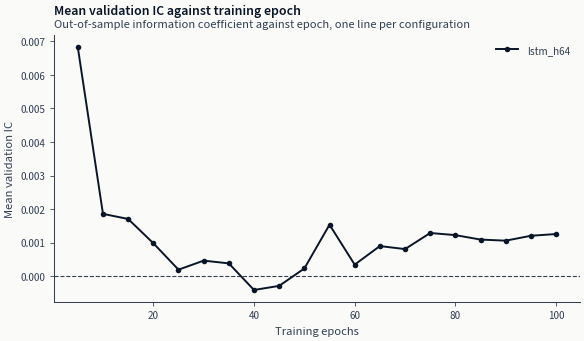

In [12]:
curves = scored.sort("config_name", "checkpoint_value")
config_names = curves.get_column("config_name").unique(maintain_order=True).to_list()
# `ml4t_palette` returns a list of that many colours, so it is called once and indexed.
palette = ml4t_palette(len(config_names), categorical=True)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for index, config_name in enumerate(config_names):
    series = curves.filter(pl.col("config_name") == config_name)
    ax.plot(
        series.get_column("checkpoint_value"),
        series.get_column("ic_mean"),
        marker="o",
        markersize=4,
        lw=1.4,
        color=palette[index],
        label=config_name,
    )
zero_line(ax)
ax.set_xlabel("Training epochs")
ax.set_ylabel("Mean validation IC")
ax.legend(fontsize=8, frameon=False)
add_message_title(
    ax,
    "Mean validation IC against training epoch",
    subtitle="Out-of-sample information coefficient against epoch, one line per configuration",
)
# The alt text counts rather than asserts: whether a curve turns over is the question the figure
# exists to answer, and a line described as peaking when it does not is a claim the data refutes.
_peaks = (
    curves.group_by("config_name")
    .agg(
        peak=pl.col("checkpoint_value").sort_by("ic_mean", descending=True).first(),
        first=pl.col("checkpoint_value").min(),
        last=pl.col("checkpoint_value").max(),
    )
    .with_columns(
        interior=pl.col("peak").is_between(pl.col("first"), pl.col("last"), closed="none")
    )
)
_n_interior = int(_peaks.get_column("interior").sum())
show_with_alt(
    fig,
    "A line chart of mean validation information coefficient against training epoch, one line per "
    "configuration, with a dashed line at zero. Counted from the underlying frame, "
    f"{_n_interior} of {_peaks.height} configurations reach their highest information coefficient "
    "at an epoch that is neither the first nor the last, which is what an interior optimum looks "
    "like.",
)

In [13]:
coverage_rows = []
for run in execution.runs:
    if not run.training.complete:
        raise RuntimeError(f"Incomplete training result: {run.training.hash}")
    for prediction in run.predictions:
        record = prediction.registry_record()
        coverage = prediction.coverage()
        if not prediction.complete or coverage is None or coverage["status"] != "complete":
            raise RuntimeError(f"Incomplete prediction result: {prediction.hash}")
        coverage_rows.append(
            {
                "config_name": run.training.spec()["config_name"],
                "checkpoint": record["checkpoint_value"],
                "training_hash": run.training.hash,
                "prediction_hash": prediction.hash,
                "coverage_status": coverage["status"],
                "expected_rows": coverage["n_expected"],
                "actual_rows": coverage["n_actual"],
                "training_artifacts": len(run.training.artifacts()),
                "prediction_artifacts": len(prediction.artifacts()),
            }
        )

coverage_table = pl.DataFrame(coverage_rows).sort("config_name", "checkpoint")
coverage_table

config_name,checkpoint,training_hash,prediction_hash,coverage_status,expected_rows,actual_rows,training_artifacts,prediction_artifacts
str,i64,str,str,str,i64,i64,i64,i64
"""lstm_h64""",5,"""69645aa3f18e""","""885ca061472c""","""complete""",6653283,6653283,1260,1
"""lstm_h64""",10,"""69645aa3f18e""","""dcf0b52d6d76""","""complete""",6653283,6653283,1260,1
"""lstm_h64""",15,"""69645aa3f18e""","""6f2ff30262cf""","""complete""",6653283,6653283,1260,1
"""lstm_h64""",20,"""69645aa3f18e""","""f8b7fc2416d9""","""complete""",6653283,6653283,1260,1
"""lstm_h64""",25,"""69645aa3f18e""","""0e2e83212a74""","""complete""",6653283,6653283,1260,1
…,…,…,…,…,…,…,…,…
"""lstm_h64""",80,"""69645aa3f18e""","""5442540b5d6a""","""complete""",6653283,6653283,1260,1
"""lstm_h64""",85,"""69645aa3f18e""","""f0016a2721ce""","""complete""",6653283,6653283,1260,1
"""lstm_h64""",90,"""69645aa3f18e""","""c47d415dbafe""","""complete""",6653283,6653283,1260,1


In [14]:
execution_diagnostics = pl.DataFrame(execution.diagnostics)
execution_diagnostics

status,training_hash,reused
str,str,bool
"""completed""","""69645aa3f18e""",false


## 6. Naming the sets the later notebooks open

A canonical default CUDA run freezes what it produced under two stable names, and preview or
customized canonical requests publish neither.

The first name is the **full set**: every prediction row this run returned, which
[`16_backtest`](16_backtest.ipynb) backtests member by member.

The second is the **bounded diagnostic set**, and it is bounded hard.
[`15_model_analysis`](15_model_analysis.ipynb) loads every diagnostic member's raw prediction
frame and holds them all while it joins them pairwise; one frame on this panel is over seven
million rows and about 225 MB in memory, so a set that grew with the checkpoint count would not fit
beside the other seven families'. The bound is the last checkpoint of each published
configuration - one member here, because the menu declares one LSTM configuration. The
epoch dimension is still read, in the learning-curve figure above, which is drawn from registry
metrics rather than from raw frames.

In [15]:
set_rows = []
if is_published_population:
    label_name = label.replace("_", "-")
    full_set_name = f"us-equities-{label_name}-lstm-v1"
    full_set = study.predictions.freeze(
        execution.catalog_rows,
        name=full_set_name,
        supersedes=candidate_set_supersedes(
            study, name=full_set_name, declared=SUPERSEDES_SETS.get(full_set_name, "")
        ),
    )
    diagnostic_rows = execution.catalog_rows.filter(
        # `.fill_null(True)` covers a family that publishes no checkpoint value at all, where the
        # comparison is null rather than false and would otherwise empty the frame.
        (
            pl.col("checkpoint_value") == pl.col("checkpoint_value").max().over("config_name")
        ).fill_null(True)
    )
    diagnostic_set_name = f"us-equities-{label_name}-lstm-diagnostics-v1"
    diagnostic_set = study.predictions.freeze(
        diagnostic_rows,
        name=diagnostic_set_name,
        supersedes=candidate_set_supersedes(
            study, name=diagnostic_set_name, declared=SUPERSEDES_SETS.get(diagnostic_set_name, "")
        ),
    )
    set_rows = [
        {
            "role": "backtest population",
            "set_name": full_set.name,
            "members": len(full_set.members),
        },
        {
            "role": "bounded diagnostics",
            "set_name": diagnostic_set.name,
            "members": len(diagnostic_set.members),
        },
    ]
compatible_sets = pl.DataFrame(
    set_rows,
    schema={"role": pl.String, "set_name": pl.String, "members": pl.Int64},
)
compatible_sets

role,set_name,members
str,str,i64
"""backtest population""","""us-equities-fwd-ret-1d-lstm-v1""",20
"""bounded diagnostics""","""us-equities-fwd-ret-1d-lstm-di…",1


`15_model_analysis` reopens both names: the full set to confirm the run filled every member it
promised, and the diagnostic set to read raw predictions. `16_backtest` passes every full-set
catalog row to the shared backtest runner. Neither the metrics here nor the ones there choose a
configuration or a checkpoint; selection is on validation backtest Sharpe in `16_backtest`.

## What to notice

**Read this against [`09_dl_nlinear`](09_dl_nlinear.ipynb) rather than on its own.** The two read
identical windows over identical folds, so the difference between them is what recurrence and
the gating bought on this panel and nothing else.

**More capacity is not free at this window count.** The training examples are windows of
consecutive sessions, not panel rows, and a two-layer recurrent network has far more parameters
to estimate from them than a single linear map does. The learning curve above is the evidence
about whether that capacity was supportable here: a curve that turns over says the extra
parameters were being spent on the training windows by the end.

**A checkpoint is part of a configuration.** Twenty per configuration, each registered
separately, for the reason `09_dl_nlinear` gives.

**Known limitations.** Windows are built only where sessions are unbroken, so the training set
is not a uniform sample of the panel. Everything here is ranking accuracy on validation folds
read many times over, and none of it is a statement about tradability.

**Next**: [`11_dl_tsmixer`](11_dl_tsmixer.ipynb) drops recurrence entirely and mixes along the
two axes of the window in turn. It is offered rather than run: fitting a third sequence
architecture on this panel was declined at 60-80 hours of GPU, so the notebook carries no
outputs and registers nothing. Everything it needs is in place for a reader who wants them.